In [26]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

In [27]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [28]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
print(x_train.shape)
print(x_test.shape)
x_train = np.expand_dims(x_train, axis=-1) # Add channel dimension
x_test = np.expand_dims(x_test, axis=-1)
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)
(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [29]:
print(y_train.shape)
print(y_test.shape)

(60000,)
(10000,)


In [30]:
print(y_train[0])

5


In [31]:
model = keras.Sequential([
layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
layers.MaxPooling2D((2, 2)),
layers.Conv2D(64, (3, 3), activation="relu"),
layers.MaxPooling2D((2, 2)),
layers.Flatten(),
layers.Dense(128, activation="relu"),
layers.Dense(10, activation="softmax") # 10 classes for MNIST digits
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
model.compile(optimizer="adam",

loss="sparse_categorical_crossentropy", # labels are in integer
metrics=["accuracy"])

In [34]:
model.fit(x_train, y_train, epochs=1, batch_size=32, validation_data=(x_test, y_test))

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 72s 37ms/step - accuracy: 0.9618 - loss: 0.1240 - val_accuracy: 0.9850 - val_loss: 0.0457


In [35]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9850 - loss: 0.0457
Test accuracy: 0.9850


In [36]:
predictions = model.predict(x_test[:5])
print(predictions.shape)
predicted_labels = np.argmax(predictions, axis=1)
print("Predicted labels:", predicted_labels)
print("Actual labels: ", y_test[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step
(5, 10)
Predicted labels: [7 2 1 0 4]
Actual labels:  [7 2 1 0 4]


##7 Exercise.
Implement an End to End CNN Model for Image Classification Task.

##Task 1: Data Understanding and Visualization:
Download the Provided Data and Complete the following task.

1. Load and visualize images from a dataset stored in directories, where each subdirec-
tory represents a class. You are expected to write a code:

• Get the list of class directories from the train folder.
• Select one image randomly from each class.
• Display the images in a grid format with two rows using matplotlib.
• Expected Output:

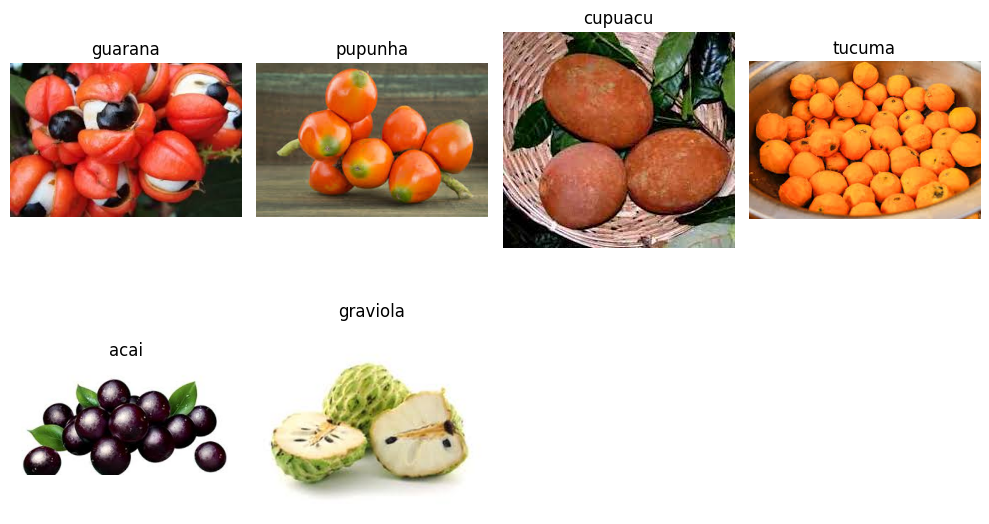

In [3]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

train_dir = "/content/drive/MyDrive/AI and Machine Learning/Week5/FruitinAmazon/FruitinAmazon/train"

classes = os.listdir(train_dir)

images = []
labels = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)
    images.append(img)
    labels.append(cls)

# Display images (2 rows grid)
plt.figure(figsize=(10, 6))

for i in range(len(images)):
    plt.subplot(2, len(images)//2 + 1, i+1)
    plt.imshow(images[i])
    plt.title(labels[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

##• What did you Observe?

Each folder represents a fruit class

Images vary in size, lighting, and angle

Some classes may have more samples than others

##2. Check for Corrupted Image: Write a script that verifies whether the image in the train
directory are valid. If any corrupted images are found, the script must remove the image from
the directory and print the message which image have been removed, if none found print ”No
Corrupted Images Found.”
• Hint:
– Iterate through each class subdirectory and check if each image is valid.
– Use the Image.open() function to attempt to load each image.
– If the image is corrupted i.e. raises an IOError or SyntaxError, remove the image from
the directory and print f"Removed corrupted image: {image_path}".
– Maintain a list of all corrupted image paths for reporting.

In [4]:
from PIL import Image
import os

corrupted = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except:
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted) == 0:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


##Task 2: Loading and Preprocessing Image Data in keras:

In [5]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# Normalize
rescale = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


##Data activation:

In [ ]:
layers.Flatten(),
layers.Dense(64, activation='relu'),
layers.Dropout(0.3), 
layers.Dense(128, activation='relu'),
layers.Dense(num_classes, activation='softmax')

<Dense name=dense_8, built=False>

##Task 3 - Implement a CNN with

##Convolutional Architecture:
• Convolutional Layer 1:
– Filter Size (F): (3, 3)
– Number of Filters (k): 32
– Padding (P): same
– Stride (s): 1

• Activation Layer: ReLU activation

• Pooling Layer 1: Max pooling
– Filter Size (F): (2, 2)
– Stride (s): 2

• Convolutional Layer 2:
– Filter Size (F): (3, 3)
– Number of Filters (k): 32
– Padding (P): same
– Stride (s): 1

• Activation Layer: ReLU activation

• Pooling Layer 2: Max pooling
– Filter Size (F): (2, 2)
– Stride (s):2

Fully Connected Network Architecture:
• Flatten Layer: Flatten the input coming from the convolutional layers

• Input Layer:

• Hidden Layer - 2:

– Number of Neurons: 64,
– Number of Neurons: 128

In [19]:
from tensorflow.keras import layers, models

num_classes = len(classes)

model = models.Sequential([
    # Conv Block 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    # Conv Block 2
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Fully Connected
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

##Task 4: Compile the Model

In [20]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

##Task 4: Train the Model
Model Training
• Use the model.fit() function to train the model. Set the batch size to 16 and the number of epochs
to 250.

• Use val ds for validation.

• Use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model and avoid-
ing overfitting.

In [21]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint("best_model.h5", save_best_only=True)
earlystop = EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=16,
    callbacks=[checkpoint, earlystop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 673ms/step - accuracy: 0.1348 - loss: 2.0709

3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.1389 - loss: 2.1836 - val_accuracy: 0.0000e+00 - val_loss: 1.9025
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 522ms/step - accuracy: 0.2546 - loss: 1.9490

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 758ms/step - accuracy: 0.2639 - loss: 1.9119 - val_accuracy: 0.0556 - val_loss: 1.8333
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.2853 - loss: 1.7017

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 609ms/step - accuracy: 0.2778 - loss: 1.6958 - val_accuracy: 0.3889 - val_loss: 1.6521
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 482ms/step - accuracy: 0.2500 - loss: 1.6662 - val_accuracy: 0.3333 - val_loss: 1.6643
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.4711 - loss: 1.5381

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 554ms/step - accuracy: 0.4444 - loss: 1.5436 - val_accuracy: 0.5000 - val_loss: 1.5958
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.6360 - loss: 1.3275

...

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 585ms/step - accuracy: 0.7917 - loss: 0.8632 - val_accuracy: 0.7778 - val_loss: 0.8176
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 586ms/step - accuracy: 0.8206 - loss: 0.7121

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 830ms/step - accuracy: 0.8056 - loss: 0.7038 - val_accuracy: 0.7778 - val_loss: 0.7636
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 646ms/step - accuracy: 0.8704 - loss: 0.4804

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 916ms/step - accuracy: 0.8611 - loss: 0.4532 - val_accuracy: 0.7222 - val_loss: 0.7069
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.7297 - loss: 0.6500

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 595ms/step - accuracy: 0.7361 - loss: 0.6634 - val_accuracy: 0.7778 - val_loss: 0.5891
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.8449 - loss: 0.4040

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 524ms/step - accuracy: 0.8472 - loss: 0.4094 - val_accuracy: 0.9444 - val_loss: 0.2792
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 515ms/step - accuracy: 0.8472 - loss: 0.4589 - val_accuracy: 0.8333 - val_loss: 0.5019
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 497ms/step - accuracy: 0.8889 - loss: 0.3483 - val_accuracy: 0.7778 - val_loss: 0.7688
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 865ms/step - accuracy: 0.8889 - loss: 0.4515 - val_accuracy: 0.8333 - val_loss: 0.4716
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 748ms/step - accuracy: 0.9167 - loss: 0.2876 - val_accuracy: 0.8889 - val_loss: 0.3661
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 503ms/step - accuracy: 0.9167 - loss: 0.2961 - val_accuracy: 0.8889 - val_loss: 0.3616
Epoch 21/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 562ms/step - accuracy: 0.9444 - loss: 0.2281 - val_accuracy: 0.8333 - val_loss: 0.4512
Epoch 22/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 507ms/step - accuracy: 0.9306 - loss: 0.2301 - val_accuracy: 0.8889 - val_lo

##Task 5: Evaluate the Model
Model Evaluation
• After training, evaluate the model using model.evaluate() on the test set to check the test
accuracy and loss.

In [22]:
loss, acc = model.evaluate(val_ds)
print("Validation Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.9444 - loss: 0.2792
Validation Accuracy: 0.9444444179534912


##Task 6: Save and Load the Model
Model Saving and Loading

• Save the trained model to an .h5 file using model.save().

• Load the saved model and re-evaluate its performance on the test set.

In [23]:
model.save("fruit_model.h5")

from tensorflow.keras.models import load_model
loaded_model = load_model("fruit_model.h5")

loaded_model.evaluate(val_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 590ms/step - accuracy: 0.9444 - loss: 0.2792


[0.2791787087917328, 0.9444444179534912]

##Task 7: Predictions and Classification Report
Making Predictions

• Use model.predict() to make predictions on test images.

• Convert the model’s predicted probabilities to digit labels using np.argmax().

• Also use from sklearn.metrics import classification report to report the Classification
Report of your Model Performance.

In [24]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

# Get unique labels from both true and predicted values
unique_labels = np.unique(np.concatenate((y_true, y_pred)))

# Create target names corresponding to the unique labels
# The `classes` variable already stores the class names in order of their integer labels.
# So, we can just pick the names using the unique_labels as indices.
display_target_names = [classes[i] for i in unique_labels if i < len(classes)]

# Ensure that the labels and target_names are aligned
print(classification_report(y_true, y_pred, labels=unique_labels, target_names=display_target_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
              precision    recall  f1-score   support

        acai       1.00      0.67      0.80         3
    graviola       0.94      1.00      0.97        15

    accuracy                           0.94        18
   macro avg       0.97      0.83      0.88        18
weighted avg       0.95      0.94      0.94        18



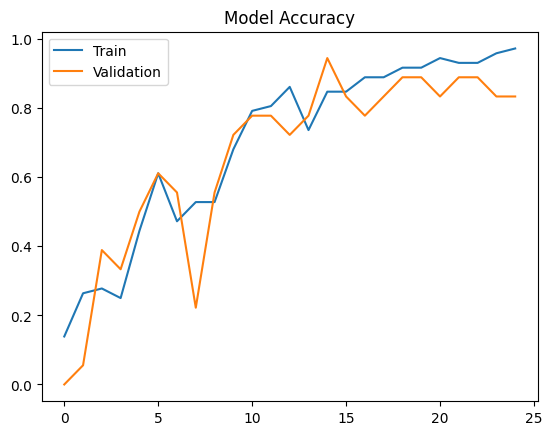

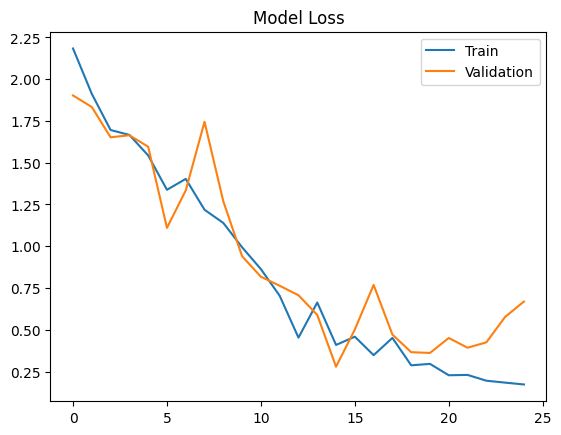

In [25]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.legend(['Train', 'Validation'])
plt.show()